# Tugas - Klasifikasi dengan Decision Tree

| Nama | NRP |
|------|-----|
| Muhammad Irzam Hafis Fabiansyah | 5054251024 |

## Deskripsi Tugas
Pada tugas ini, kalian akan membangun model Decision Tree Classifier untuk menyelesaikan sebuah masalah klasifikasi.

Dataset dapat diakses melalui link berikut:
[Company Bankruptcy Prediction](https://www.kaggle.com/datasets/fedesoriano/company-bankruptcy-prediction) (data kebangkrutan perusahaan Taiwan, 6819 sampel, 95 fitur finansial, target `Bankrupt?` biner).

Tujuan utama dari tugas ini adalah memahami cara kerja Decision Tree secara praktik, khususnya:
1. Perbedaan hasil antara kriteria split Gini Impurity dan Entropy
2. Pengaruh regularisasi (max_depth) terhadap gejala overfitting

Langkah-langkah yang harus dilakukan antara lain:
1. Persiapan Dataset dan Eksplorasi Awal
   - Memuat dataset, melihat struktur data, dan distribusi label.
2. Preprocessing
   - Memproses data agar siap digunakan dalam membangun model.
3. Eksperimen Model
   - Bangun model Decision Tree dengan kriteria Gini dan Entropy.
   - Lakukan eksperimen regularisasi dengan variasi nilai max_depth.
4. Evaluasi Model
   - Hitung metrik evaluasi dan visualisasikan hasilnya.
5. Analisis dan Kesimpulan
   - Bandingkan hasil eksperimen dan berikan kesimpulan.

# 1. Persiapan Dataset dan Eksplorasi Awal

In [1]:
# Import library yang dibutuhkan (pandas, numpy, matplotlib, seaborn, sklearn, dll)
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import kagglehub
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, classification_report, confusion_matrix)

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 100

path = kagglehub.dataset_download("fedesoriano/company-bankruptcy-prediction")
print("Path to dataset files:", path)

Path to dataset files: /home/irzam/.cache/kagglehub/datasets/fedesoriano/company-bankruptcy-prediction/versions/2


In [2]:
# Load dataset dan tampilkan informasi dasar: jumlah baris dan kolom, tipe data, statistik deskriptif, dan jumlah missing value.
df = pd.read_csv(path + "/data.csv")
df.columns = [c.strip() for c in df.columns]  # nama kolom asli berawalan spasi

print("Shape:", df.shape)
df.head()
df.info()
print("\nJumlah missing value per kolom (total):", int(df.isna().sum().sum()))
df.describe().T.head(10)

Shape: (6819, 96)
<class 'pandas.DataFrame'>
RangeIndex: 6819 entries, 0 to 6818
Data columns (total 96 columns):
 #   Column                                                   Non-Null Count  Dtype  
---  ------                                                   --------------  -----  
 0   Bankrupt?                                                6819 non-null   int64  
 1   ROA(C) before interest and depreciation before interest  6819 non-null   float64
 2   ROA(A) before interest and % after tax                   6819 non-null   float64
 3   ROA(B) before interest and depreciation after tax        6819 non-null   float64
 4   Operating Gross Margin                                   6819 non-null   float64
 5   Realized Sales Gross Margin                              6819 non-null   float64
 6   Operating Profit Rate                                    6819 non-null   float64
 7   Pre-tax net Interest Rate                                6819 non-null   float64
 8   After-tax net Interes

,count,mean,std,min,25%,50%,75%,max
Bankrupt?,6819.0,0.032263,0.176710,0.0,0.000000,0.000000,0.000000,1.0
ROA(C) before interest and depreciation before interest,6819.0,0.505180,0.060686,0.0,0.476527,0.502706,0.535563,1.0
ROA(A) before interest and % after tax,6819.0,0.558625,0.065620,0.0,0.535543,0.559802,0.589157,1.0
ROA(B) before interest and depreciation after tax,6819.0,0.553589,0.061595,0.0,0.527277,0.552278,0.584105,1.0
Operating Gross Margin,6819.0,0.607948,0.016934,0.0,0.600445,0.605997,0.613914,1.0
Realized Sales Gross Margin,6819.0,0.607929,0.016916,0.0,0.600434,0.605976,0.613842,1.0
Operating Profit Rate,6819.0,0.998755,0.013010,0.0,0.998969,0.999022,0.999095,1.0
Pre-tax net Interest Rate,6819.0,0.797190,0.012869,0.0,0.797386,0.797464,0.797579,1.0
After-tax net Interest Rate,6819.0,0.809084,0.013601,0.0,0.809312,0.809375,0.809469,1.0
Non-industry income and expenditure/revenue,6819.0,0.303623,0.011163,0.0,0.303466,0.303525,0.303585,1.0


Bankrupt?
0    6599
1     220
Name: count, dtype: int64
Bankrupt?
0    0.9677
1    0.0323
Name: proportion, dtype: float64


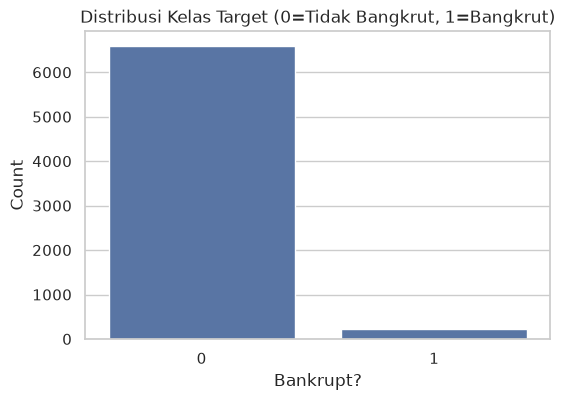

In [3]:
# Tampilkan distribusi kelas target dalam bentuk bar plot.
# Perhatikan apakah dataset ini imbalanced.
print(df["Bankrupt?"].value_counts())
print(df["Bankrupt?"].value_counts(normalize=True).round(4))

plt.figure(figsize=(6, 4))
sns.countplot(data=df, x="Bankrupt?")
plt.title("Distribusi Kelas Target (0=Tidak Bangkrut, 1=Bangkrut)")
plt.xlabel("Bankrupt?")
plt.ylabel("Count")
plt.show()

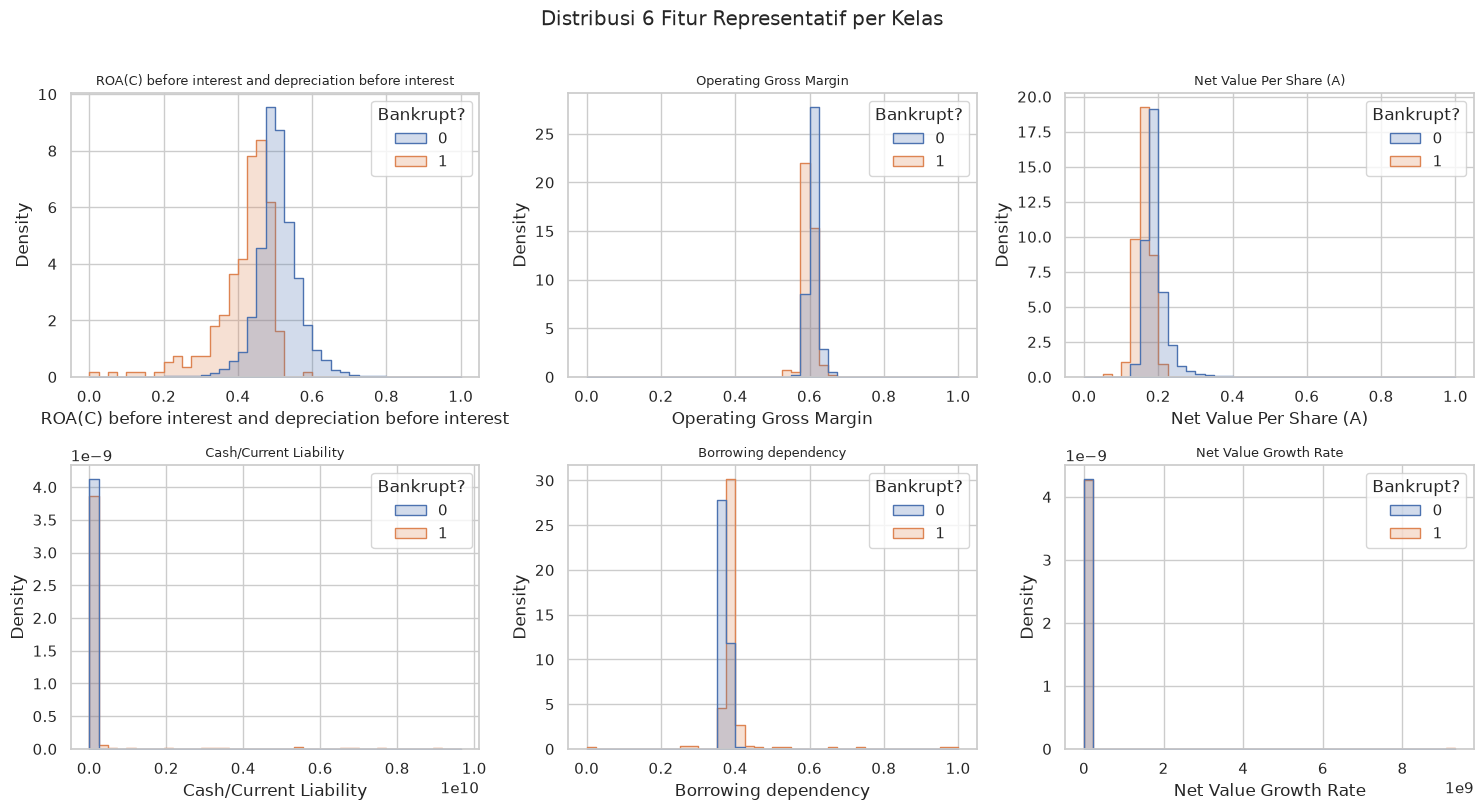

In [4]:
# Tampilkan distribusi atau hubungan antar fitur (histogram, boxplot, atau pairplot), dibedakan berdasarkan kelas target.
# Ini membantu melihat apakah ada fitur yang punya batas pemisah yang jelas antar kelas.
# Karena ada 95 fitur, pairplot seluruh fitur tidak feasible -> gunakan 6 fitur representatif.
rep_features = ["ROA(C) before interest and depreciation before interest",
                "Operating Gross Margin",
                "Net Value Per Share (A)",
                "Cash/Current Liability",
                "Borrowing dependency",
                "Net Value Growth Rate"]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, feat in zip(axes.flatten(), rep_features):
    sns.histplot(data=df, x=feat, hue="Bankrupt?", bins=40, element="step",
                 stat="density", common_norm=False, ax=ax)
    ax.set_title(feat, fontsize=9)
plt.suptitle("Distribusi 6 Fitur Representatif per Kelas", y=1.01)
plt.tight_layout()
plt.show()

## Lakukan Exploratory Data Analysis (EDA) tambahan yang diperlukan.

Net Income to Total Assets                                -0.3155
ROA(A) before interest and % after tax                    -0.2829
ROA(B) before interest and depreciation after tax         -0.2731
ROA(C) before interest and depreciation before interest   -0.2608
Net worth/Assets                                          -0.2502
Debt ratio %                                               0.2502
Persistent EPS in the Last Four Seasons                   -0.2196
Retained Earnings to Total Assets                         -0.2178
Net profit before tax/Paid-in capital                     -0.2079
Per Share Net profit before tax (Yuan ¥)                  -0.2014
Current Liability to Assets                                0.1945
Working Capital to Total Assets                           -0.1931
Net Income to Stockholder's Equity                        -0.1810
Borrowing dependency                                       0.1765
Current Liability to Current Assets                        0.1713
Name: Bank

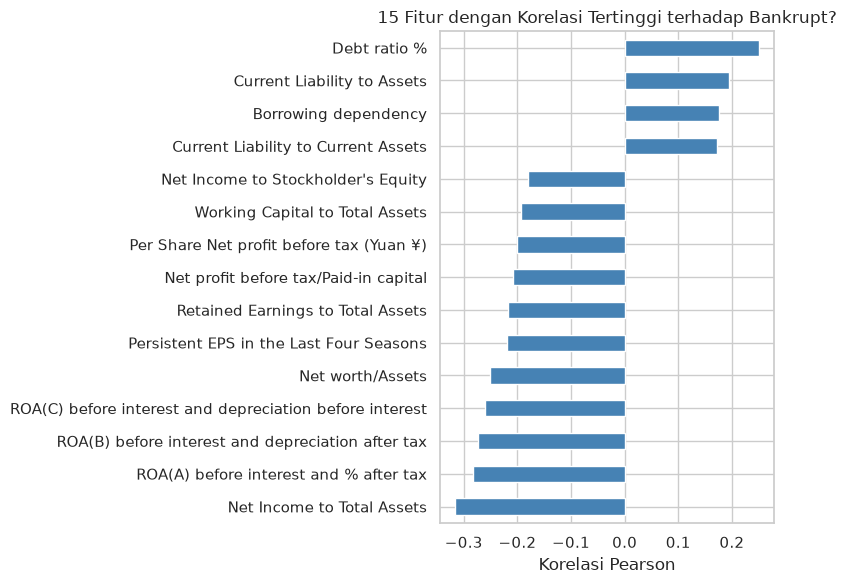

In [5]:
# EDA tambahan 1: korelasi tiap fitur terhadap target -> 15 fitur paling berkorelasi.
corr_target = df.corr(numeric_only=True)["Bankrupt?"].drop("Bankrupt?").sort_values(key=abs, ascending=False)
print(corr_target.head(15).round(4))

plt.figure(figsize=(8, 6))
corr_target.head(15).sort_values().plot(kind="barh", color="steelblue")
plt.title("15 Fitur dengan Korelasi Tertinggi terhadap Bankrupt?")
plt.xlabel("Korelasi Pearson")
plt.tight_layout()
plt.show()

In [6]:
# EDA tambahan 2: perbandingan rata-rata fitur antar kelas + cek duplikat.
print("Jumlah baris duplikat:", int(df.duplicated().sum()))
compare = df.groupby("Bankrupt?")[corr_target.head(8).index.tolist()].mean().T
compare.columns = ["Tidak Bangkrut (0)", "Bangkrut (1)"]
compare.round(4)

Jumlah baris duplikat: 0


,Tidak Bangkrut (0),Bangkrut (1)
Net Income to Total Assets,0.8101,0.7381
ROA(A) before interest and % after tax,0.5620,0.4569
ROA(B) before interest and depreciation after tax,0.5567,0.4615
ROA(C) before interest and depreciation before interest,0.5081,0.4185
Net worth/Assets,0.8893,0.8130
Debt ratio %,0.1107,0.1870
Persistent EPS in the Last Four Seasons,0.2301,0.1888
Retained Earnings to Total Assets,0.9357,0.9042


# 2. Preprocessing

In [7]:
# Tangani missing value (jika ada) dengan strategi yang sesuai.
# Pastikan strategi yang dipilih tidak memperkenalkan data leakage.
print("Missing value per kolom (5 teratas):")
print(df.isna().sum().sort_values(ascending=False).head())
print("\nTotal missing:", int(df.isna().sum().sum()))
print("Duplikat:", int(df.duplicated().sum()))
# Hasil: tidak ada missing value dan tidak ada duplikat, sehingga tidak ada imputasi/drop yang diperlukan.
# (Jika ada, imputasi median harus di-fit hanya pada train set agar tidak terjadi leakage.)

Missing value per kolom (5 teratas):
Bankrupt?                                                  0
ROA(C) before interest and depreciation before interest    0
ROA(A) before interest and % after tax                     0
ROA(B) before interest and depreciation after tax          0
Operating Gross Margin                                     0
dtype: int64

Total missing: 0
Duplikat: 0


In [8]:
# Jika terdapat fitur kategorikal, lakukan encoding yang sesuai (misalnya One-Hot Encoding atau Ordinal Encoding).
# Catatan: Decision Tree secara konsep bisa menangani fitur kategorikal secara langsung tanpa One-Hot Encoding,
# tetapi implementasi DecisionTreeClassifier pada scikit-learn tetap mengharuskan input berupa angka.
print(df.dtypes.value_counts())
obj_cols = df.select_dtypes(include="object").columns.tolist()
print("Kolom non-numerik:", obj_cols)
# Hasil: seluruh 96 kolom bertipe numerik (float64/int64), tidak ada fitur kategorikal -> tidak perlu encoding.

float64    93
int64       3
Name: count, dtype: int64
Kolom non-numerik: []


In [9]:
# Pisahkan fitur (X) dan target (y).
# Bagi data menjadi train set dan test set (misalnya 80:20).
# Gunakan stratify=y agar distribusi kelas tetap proporsional.
X = df.drop(columns=["Bankrupt?"])
y = df["Bankrupt?"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print("X_train:", X_train.shape, " X_test:", X_test.shape)
print("\nProporsi kelas train:\n", y_train.value_counts(normalize=True).round(4))
print("\nProporsi kelas test:\n", y_test.value_counts(normalize=True).round(4))

X_train: (5455, 95)  X_test: (1364, 95)

Proporsi kelas train:
 Bankrupt?
0    0.9677
1    0.0323
Name: proportion, dtype: float64

Proporsi kelas test:
 Bankrupt?
0    0.9677
1    0.0323
Name: proportion, dtype: float64


**Catatan penting:** Decision Tree tidak memerlukan feature scaling (StandardScaler/MinMaxScaler). Split pada Decision Tree dilakukan berdasarkan threshold per fitur satu per satu, bukan berdasarkan jarak antar titik seperti pada KNN atau SVM. Jadi kalian tidak perlu melakukan scaling pada tahap ini.

# 3. Eksperimen Model

## 3.1 Decision Tree dengan Kriteria Gini

Gini Impurity adalah kriteria default pada DecisionTreeClassifier di scikit-learn. Kriteria ini mengukur peluang kesalahan klasifikasi jika sebuah sampel dipilih secara acak dari suatu node.

In [10]:
# Inisialisasi dan latih model DecisionTreeClassifier dengan criterion='gini' menggunakan train set.
dt_gini = DecisionTreeClassifier(criterion="gini", random_state=42)
dt_gini.fit(X_train, y_train)
print("Kedalaman pohon (gini):", dt_gini.get_depth(), "| Jumlah daun:", dt_gini.get_n_leaves())
print("Akurasi train (gini):", round(dt_gini.score(X_train, y_train), 4))

Kedalaman pohon (gini): 20 | Jumlah daun: 124
Akurasi train (gini): 1.0


In [11]:
# Lakukan prediksi pada test set.
# Simpan hasil prediksi label untuk keperluan evaluasi.
y_pred_gini = dt_gini.predict(X_test)
print("Akurasi test (gini):", round(accuracy_score(y_test, y_pred_gini), 4))

Akurasi test (gini): 0.9611


## 3.2 Decision Tree dengan Kriteria Entropy

Entropy (Information Gain) adalah kriteria alternatif yang mengukur tingkat ketidakpastian distribusi kelas pada suatu node.

In [12]:
# Inisialisasi dan latih model DecisionTreeClassifier dengan criterion='entropy' menggunakan train set.
# Gunakan nilai hyperparameter lain yang sama seperti model Gini di atas, agar perbandingan adil.
dt_entropy = DecisionTreeClassifier(criterion="entropy", random_state=42)
dt_entropy.fit(X_train, y_train)
print("Kedalaman pohon (entropy):", dt_entropy.get_depth(), "| Jumlah daun:", dt_entropy.get_n_leaves())
print("Akurasi train (entropy):", round(dt_entropy.score(X_train, y_train), 4))

Kedalaman pohon (entropy): 17 | Jumlah daun: 99
Akurasi train (entropy): 1.0


In [13]:
# Lakukan prediksi pada test set.
# Simpan hasil prediksi label untuk keperluan evaluasi.
y_pred_entropy = dt_entropy.predict(X_test)
print("Akurasi test (entropy):", round(accuracy_score(y_test, y_pred_entropy), 4))

Akurasi test (entropy): 0.9641


## 3.3 Eksperimen Regularisasi: Pengaruh max_depth terhadap Overfitting

Decision Tree yang dibiarkan tumbuh tanpa batas cenderung overfitting terhadap data training. Pada bagian ini kalian akan mengamati bagaimana perubahan nilai max_depth memengaruhi akurasi training dan testing.

In [14]:
# Latih beberapa model DecisionTreeClassifier dengan variasi nilai max_depth,
# misalnya 1, 2, 3, 5, 10, dan None (tanpa batas kedalaman).
# Gunakan kriteria split terbaik dari salah satu percobaan sebelumnya (Gini atau Entropy).
# -> Entropy sedikit lebih baik pada test set, sehingga dipakai di sini.
depths = [1, 2, 3, 5, 10, 15, None]
train_acc, test_acc = [], []
for d in depths:
    m = DecisionTreeClassifier(criterion="entropy", max_depth=d, random_state=42)
    m.fit(X_train, y_train)
    train_acc.append(m.score(X_train, y_train))
    test_acc.append(m.score(X_test, y_test))
    print(f"max_depth={d}: train={train_acc[-1]:.4f}, test={test_acc[-1]:.4f}")

max_depth=1: train=0.9677, test=0.9677
max_depth=2: train=0.9677, test=0.9677


max_depth=3: train=0.9683, test=0.9699
max_depth=5: train=0.9743, test=0.9663


max_depth=10: train=0.9930, test=0.9633
max_depth=15: train=0.9993, test=0.9626


max_depth=None: train=1.0000, test=0.9641


In [15]:
# Hitung akurasi pada train set dan test set untuk setiap nilai max_depth yang dicoba.
# Simpan hasilnya dalam list atau dictionary agar mudah diplot.
depth_results = pd.DataFrame({
    "max_depth": [str(d) for d in depths],
    "train_acc": train_acc,
    "test_acc": test_acc,
})
depth_results.round(4)

,max_depth,train_acc,test_acc
0,1,0.9677,0.9677
1,2,0.9677,0.9677
2,3,0.9683,0.9699
3,5,0.9743,0.9663
4,10,0.9930,0.9633
5,15,0.9993,0.9626
6,None,1.0000,0.9641


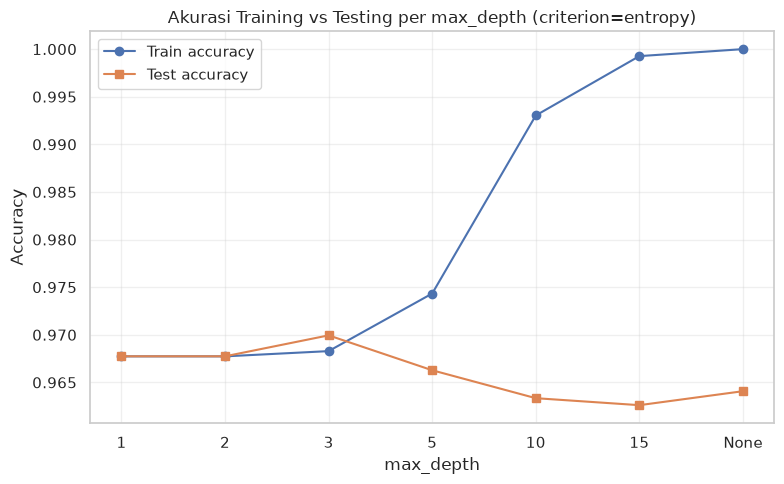

In [16]:
# Plot grafik akurasi training vs testing terhadap max_depth dalam satu chart.
# Amati pada titik berapa model mulai menunjukkan gejala overfitting
# (akurasi training terus naik, sementara akurasi testing mulai stagnan atau menurun).
x = np.arange(len(depths))
plt.figure(figsize=(8, 5))
plt.plot(x, train_acc, marker="o", label="Train accuracy")
plt.plot(x, test_acc, marker="s", label="Test accuracy")
plt.xticks(x, [str(d) for d in depths])
plt.xlabel("max_depth")
plt.ylabel("Accuracy")
plt.title("Akurasi Training vs Testing per max_depth (criterion=entropy)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# 4. Evaluasi Model

In [17]:
# Tampilkan metrik evaluasi (Accuracy, Precision, Recall, F1-Score) untuk model Gini dan Entropy.
# Sajikan dalam satu tabel perbandingan agar mudah dibandingkan.
# Catatan: karena data sangat imbalanced (3.2% positif), precision/recall/F1 kelas bangkrut jauh lebih informatif dari accuracy.
summary = pd.DataFrame({
    "Gini": [accuracy_score(y_test, y_pred_gini),
             precision_score(y_test, y_pred_gini, zero_division=0),
             recall_score(y_test, y_pred_gini, zero_division=0),
             f1_score(y_test, y_pred_gini, zero_division=0)],
    "Entropy": [accuracy_score(y_test, y_pred_entropy),
                precision_score(y_test, y_pred_entropy, zero_division=0),
                recall_score(y_test, y_pred_entropy, zero_division=0),
                f1_score(y_test, y_pred_entropy, zero_division=0)],
}, index=["Accuracy", "Precision", "Recall", "F1-Score"])
summary.round(4)
print(classification_report(y_test, y_pred_entropy, target_names=["Tidak Bangkrut", "Bangkrut"]))
summary.round(4)

                precision    recall  f1-score   support

Tidak Bangkrut       0.98      0.98      0.98      1320
      Bangkrut       0.44      0.39      0.41        44

      accuracy                           0.96      1364
     macro avg       0.71      0.68      0.70      1364
  weighted avg       0.96      0.96      0.96      1364



,Gini,Entropy
Accuracy,0.9611,0.9641
Precision,0.4000,0.4359
Recall,0.4091,0.3864
F1-Score,0.4045,0.4096


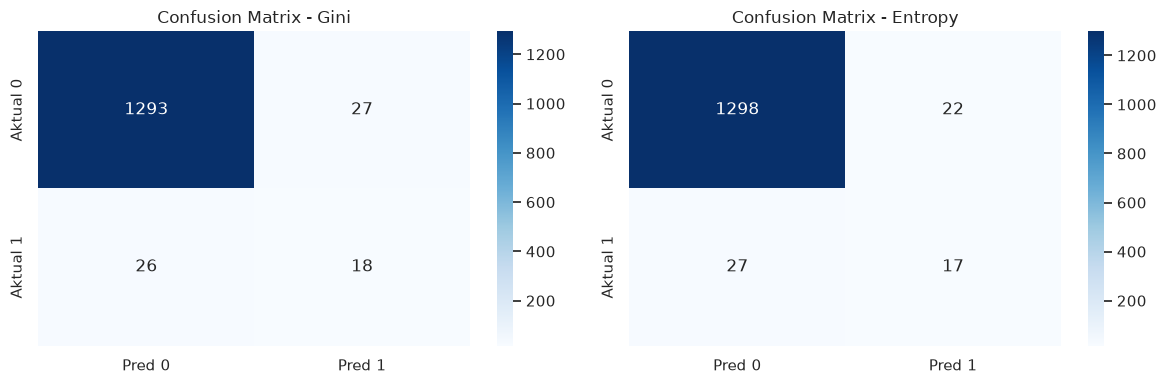

In [18]:
# Tampilkan Confusion Matrix untuk model Gini dan Entropy dalam bentuk heatmap.
# Susun keduanya dalam satu baris subplot.
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, y_pred, title in zip(axes,
                             [y_pred_gini, y_pred_entropy],
                             ["Confusion Matrix - Gini", "Confusion Matrix - Entropy"]):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax,
                xticklabels=["Pred 0", "Pred 1"], yticklabels=["Aktual 0", "Aktual 1"])
    ax.set_title(title)
plt.tight_layout()
plt.show()

Akurasi test model dangkal (entropy, max_depth=3): 0.9699


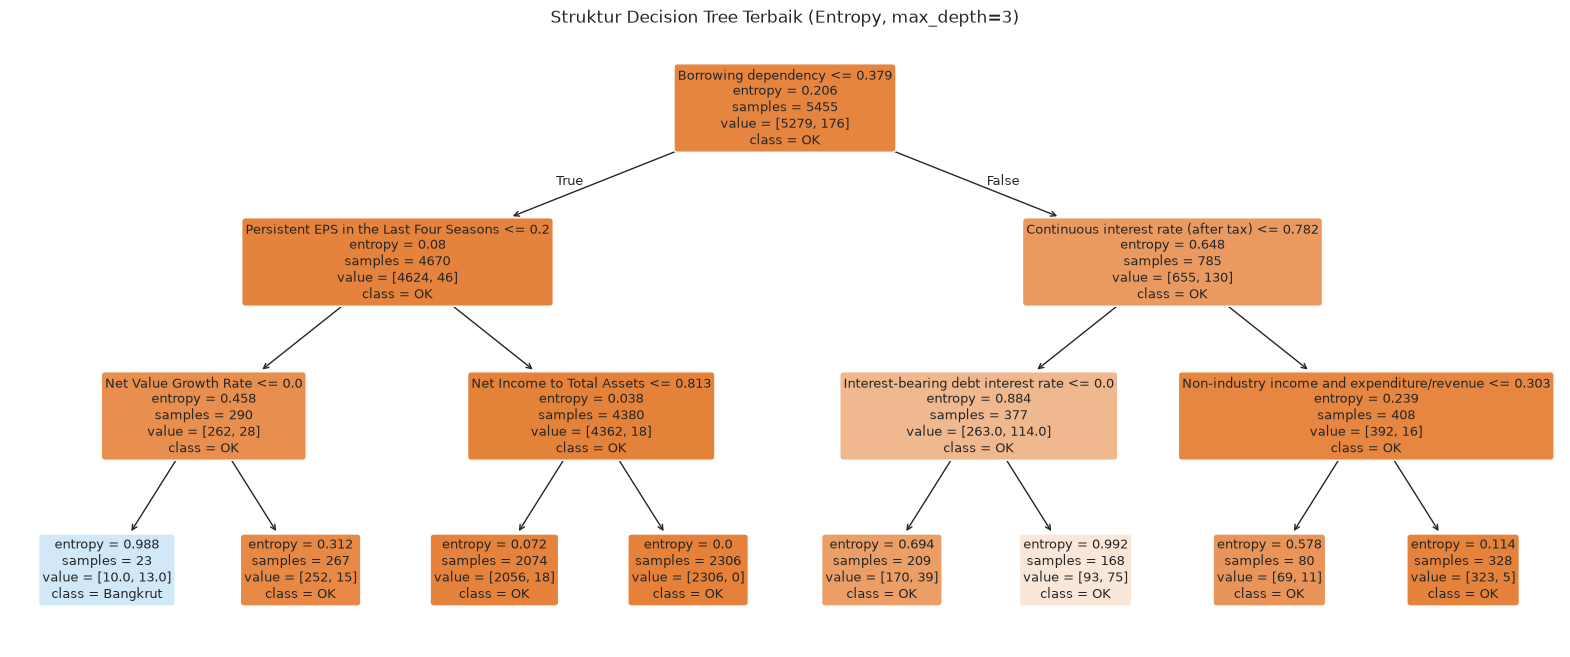

In [19]:
# Visualisasikan struktur Decision Tree (gunakan plot_tree) untuk model dengan performa terbaik.
# Batasi kedalaman visualisasi (misalnya max_depth=2 atau 3 pada parameter plot_tree) agar tetap mudah dibaca.
# Model terbaik = entropy; latih ulang versi dangkal (max_depth=3) agar visualisasi terbaca.
dt_best_shallow = DecisionTreeClassifier(criterion="entropy", max_depth=3, random_state=42)
dt_best_shallow.fit(X_train, y_train)
print("Akurasi test model dangkal (entropy, max_depth=3):",
      round(dt_best_shallow.score(X_test, y_test), 4))

plt.figure(figsize=(20, 8))
plot_tree(dt_best_shallow, filled=True, rounded=True, fontsize=9,
          feature_names=list(X.columns), class_names=["OK", "Bangkrut"],
          max_depth=3)
plt.title("Struktur Decision Tree Terbaik (Entropy, max_depth=3)")
plt.show()

Borrowing dependency                           0.2221
Continuous interest rate (after tax)           0.0758
Persistent EPS in the Last Four Seasons        0.0635
Net Value Growth Rate                          0.0517
Quick Ratio                                    0.0298
Operating Profit Growth Rate                   0.0270
Net Income to Total Assets                     0.0247
Interest-bearing debt interest rate            0.0242
Operating Expense Rate                         0.0225
Non-industry income and expenditure/revenue    0.0189
dtype: float64


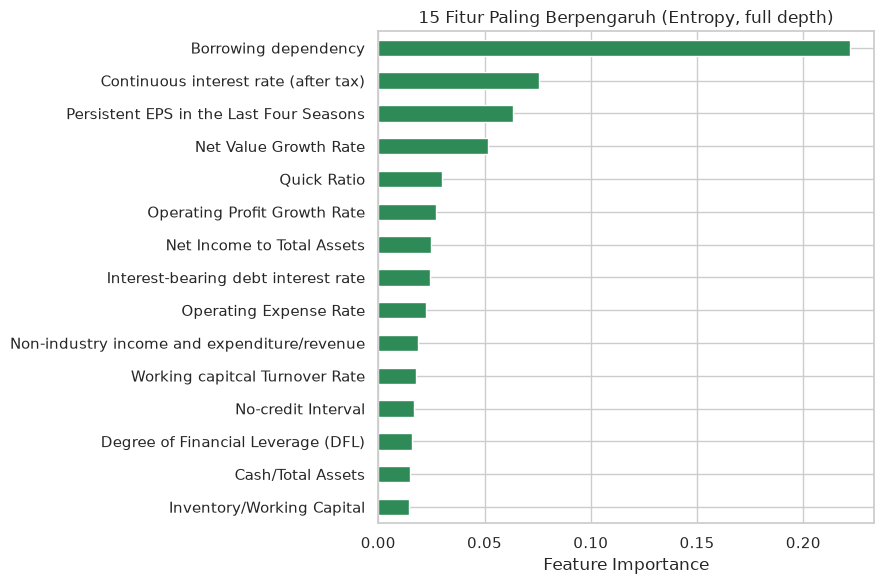

In [20]:
# Tampilkan feature importance dari model terbaik dalam bentuk bar chart horizontal.
# Urutkan dari fitur yang paling berpengaruh.
importances = pd.Series(dt_entropy.feature_importances_, index=X.columns).sort_values(ascending=False)
print(importances.head(10).round(4))

plt.figure(figsize=(9, 6))
importances.head(15).sort_values().plot(kind="barh", color="seagreen")
plt.title("15 Fitur Paling Berpengaruh (Entropy, full depth)")
plt.xlabel("Feature Importance")
plt.tight_layout()
plt.show()

# 5. Analisis

### Hasil analisis eksperimen

**1. Gini vs Entropy.** Kedua kriteria menghasilkan pohon yang sama-sama overfitting pada konfigurasi tanpa batas (akurasi train 1.0000 untuk keduanya). Pada test set, Entropy sedikit lebih baik: akurasi 0.9641 vs 0.9611, precision 0.4359 vs 0.4000, F1 0.4096 vs 0.4045; recall Gini sedikit lebih tinggi (0.4091 vs 0.3864). Perbedaannya kecil (~0.3% akurasi) dan tidak signifikan — wajar karena Gini dan Entropy adalah ukuran impurity yang berperilaku mirip (keduanya memilih split dengan gain terbesar, hanya fungsi matematikanya berbeda: `1 - sum(p^2)` vs `-sum(p log p)`). Confusion matrix menunjukkan kedua model sama-sama kesulitan mengenali kelas minoritas (hanya 17-18 dari 44 perusahaan bangkrut terdeteksi), yang merupakan konsekuensi logis dari imbalance 96.8% : 3.2%: pohon memaksimalkan akurasi global sehingga bias ke kelas mayoritas. Kesimpulan praktisnya: accuracy ~0.96 menipu — metrik yang jujur untuk kasus ini adalah precision/recall/F1 kelas bangkrut (~0.40).

**2. Regularisasi max_depth (criterion=entropy).** Hasil sweep: depth 1 → train 0.9677/test 0.9677; depth 2 → 0.9677/0.9677; depth 3 → 0.9683/0.9699 (titik terbaik test); depth 5 → 0.9743/0.9663; depth 10 → 0.9930/0.9633; depth 15 → 0.9993/0.9626; None → 1.0000/0.9641. Gejala overfitting mulai terlihat setelah max_depth=3: akurasi training terus menanjak hingga 1.0 (pohon menghafal data train, daun bertambah dari 8 menjadi ~99), sedangkan akurasi testing stagnan lalu menurun. Ciri klasiknya persis seperti teori: gap train-test melebar dan kurva test membentuk inverted-U dengan puncak di max_depth=3. Maka max_depth=3 adalah titik optimal bias-variance untuk dataset ini.

**3. Fitur paling berpengaruh.** Berdasarkan feature importance model Entropy, fitur teratas adalah Borrowing dependency (0.222), disusul Continuous interest rate after tax (0.076), Persistent EPS in the Last Four Seasons (0.064), Net Value Growth Rate (0.052), dan Quick Ratio (0.030). Ini konsisten dengan EDA korelasi (Borrowing dependency dan ROA juga muncul di puncak korelasi): ketergantungan pinjaman dan beban bunga adalah sinyal utama kebangkrutan — perusahaan dengan borrowing dependency tinggi berisiko bangkrut. Visualisasi pohon dangkal mengonfirmasi hal yang sama: split pertama/root menggunakan Borrowing dependency.

# 6. Kesimpulan dan Saran

### Kesimpulan
1. Model Decision Tree mencapai akurasi test ~0.96, tetapi karena imbalance kelas yang ekstrem, angka tersebut didominasi kelas mayoritas; kemampuan mendeteksi kebangkrutan yang sesungguhnya hanya moderat (F1 ~0.41, recall ~0.39-0.41).
2. Kriteria Entropy sedikit mengungguli Gini pada data ini (test 0.9641 vs 0.9611), namun perbedaannya tidak signifikan karena kedua fungsi impurity memilih split yang serupa.
3. Regularisasi max_depth terbukti mengendalikan overfitting: pohon tanpa batas mencapai train 1.0 dengan ~99 daun, sedangkan max_depth=3 memberi test accuracy tertinggi (0.9699) dengan pohon yang jauh lebih sederhana dan interpretable.
4. Fitur kunci prediksi adalah Borrowing dependency, Continuous interest rate after tax, dan Persistent EPS — selaras dengan intuisi finansial bahwa beban utang dan profitabilitas menentukan kebangkrutan.

### Saran
- Tangani imbalance: coba `class_weight="balanced"`, SMOTE/undersampling, atau threshold tuning untuk menaikkan recall kelas bangkrut (dengan trade-off precision).
- Coba cost-complexity pruning (`ccp_alpha`) sebagai alternatif max_depth, plus tuning `min_samples_leaf`/`min_samples_split` via cross-validation (StratifiedKFold + scoring F1).
- Bandingkan dengan ensemble (Random Forest, Gradient Boosting/XGBoost) yang biasanya jauh lebih kuat untuk data tabular imbalanced seperti ini.
- Evaluasi dengan ROC-AUC / PR-AUC agar perbandingan model lebih adil pada data imbalanced.